In [1]:
!pip install pandas matplotlib seaborn torch

Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

Defining Columns



In [3]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1,22)]
col_names = index_names + setting_names + sensor_names

Load Dataset

In [4]:
df = pd.read_csv('/content/sample_data/train_FD001.txt', sep=r'\s+' , header=None, names=col_names)


Sensor Mappings

    'sensor_1': 'T2_Fan_Inlet_Temp',
    'sensor_2': 'T24_LPC_Outlet_Temp',
    'sensor_3': 'T30_HPC_Outlet_Temp',
    'sensor_4': 'T50_LPT_Outlet_Temp',
    'sensor_5': 'P2_Fan_Inlet_Press',
    'sensor_6': 'EPR_Engine_Press_Ratio',
    'sensor_7': 'P15_Bypass_Press',
    'sensor_8': 'P30_HPC_Outlet_Press',
    'sensor_9': 'Nf_Physical_Fan_Speed',
    'sensor_10': 'Nc_Physical_Core_Speed',
    'sensor_11': 'Wf_Fuel_Flow',
    'sensor_12': 'Ps30_HPC_Outlet_Static_Press',
    'sensor_13': 'Phi_Fuel_Ratio',
    'sensor_14': 'NRf_Corrected_Fan_Speed',
    'sensor_15': 'NRc_Corrected_Core_Speed',
    'sensor_16': 'BPR_Bypass_Ratio',
    'sensor_17': 'farB_Burner_Fuel_Air_Ratio',
    'sensor_18': 'htBleed_Bleed_Enthalpy',
    'sensor_19': 'Nf_dmd_Demanded_Fan_Speed',
    'sensor_20': 'PCNf_dmd_Demanded_Corr_Fan_Speed',
    'sensor_21': 'P50_LPT_Outlet_Press'

Compute RUL

In [5]:
import pandas as pd
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1,22)]
col_names = index_names + setting_names + sensor_names
df = pd.read_csv('/content/sample_data/train_FD001.txt', sep=r'\s+' , header=None, names=col_names)

max_cycle = df.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']
df = pd.merge(df, max_cycle, on='unit_number', how='left')
df['RUL'] = df['max_cycle'] - df['time_cycles']

# Apply RUL clipping to training data
rul_clip = 125
df['RUL'] = df['RUL'].clip(upper=rul_clip)

df.drop('max_cycle', axis=1, inplace=True)
print(df.shape)

(20631, 27)


Remove:

Non Features (Engine id, cycles)

Bloat Sensors (Highly correlated)

In [6]:
feature_cols = df.columns.drop(['unit_number', 'time_cycles', 'RUL'])
stds = df[feature_cols].std()
stds.sort_values()

,0
setting_3,0.000000e+00
s_19,0.000000e+00
s_18,0.000000e+00
s_16,1.556432e-14
s_10,4.660829e-13
s_5,3.394700e-12
s_1,6.537152e-11
setting_2,2.930621e-04
s_6,1.388985e-03
setting_1,2.187313e-03


Sensor variation Plot

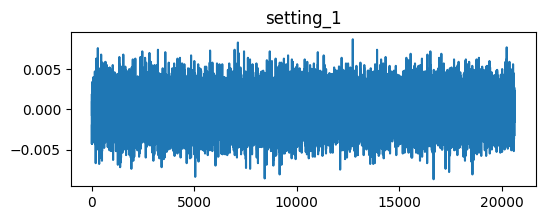

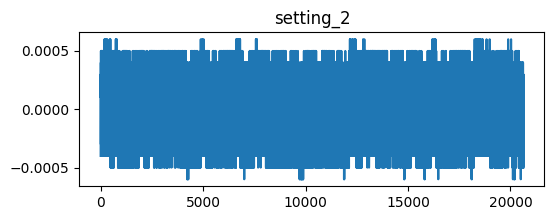

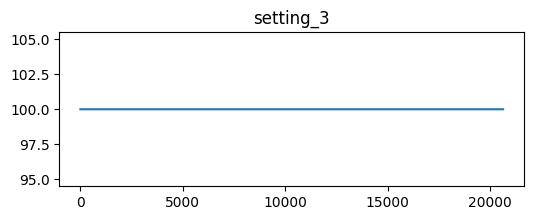

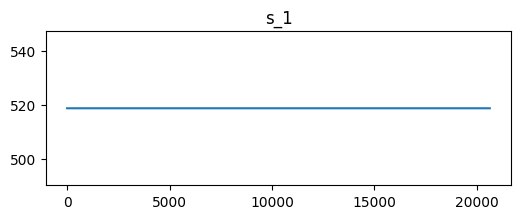

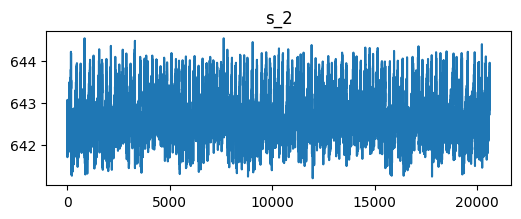

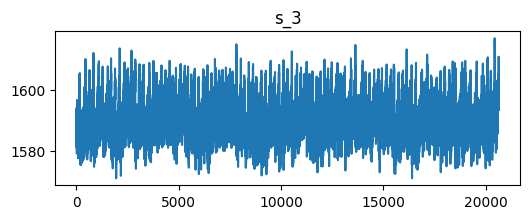

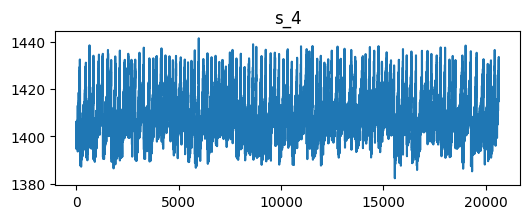

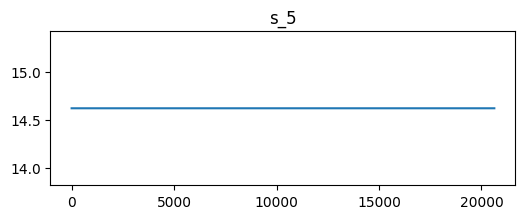

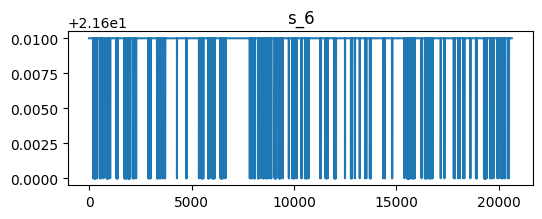

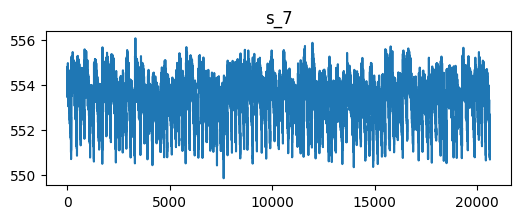

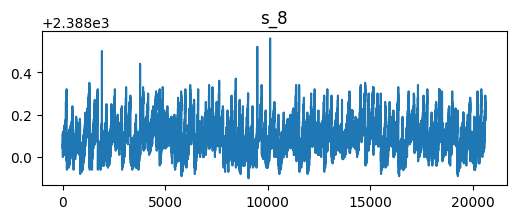

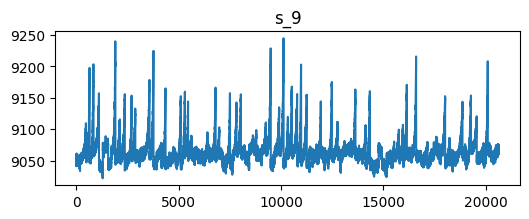

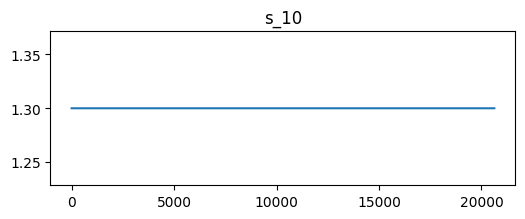

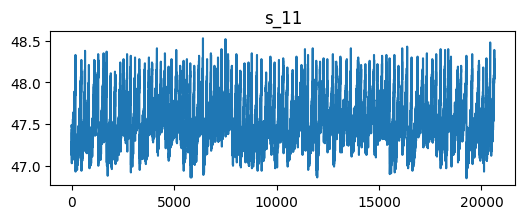

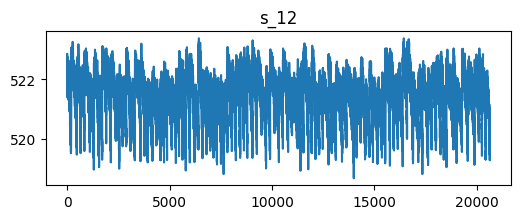

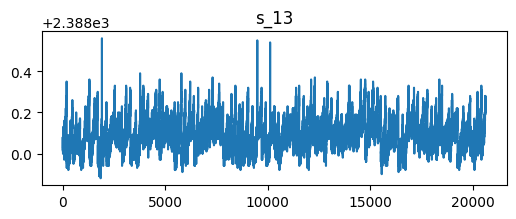

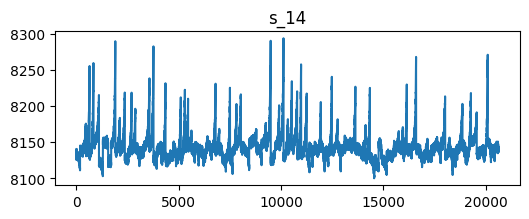

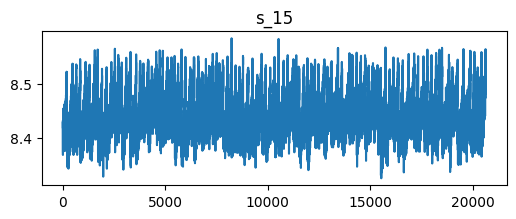

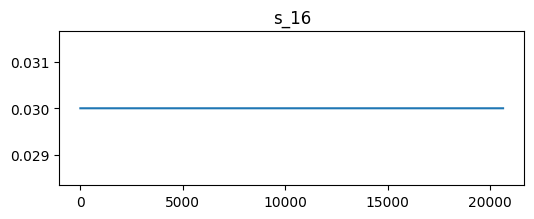

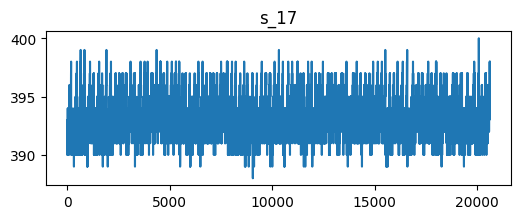

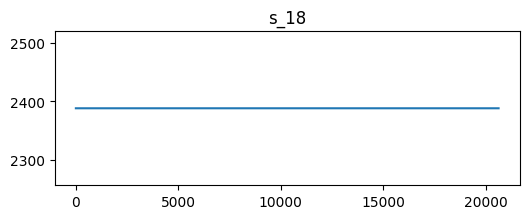

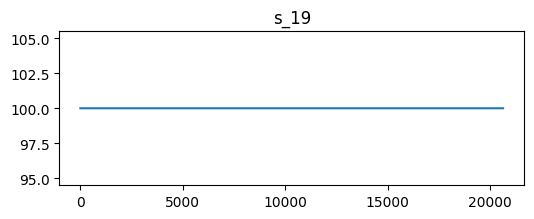

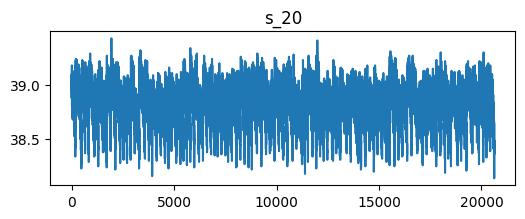

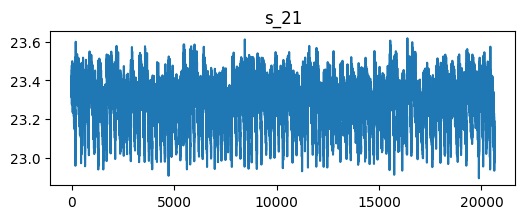

In [7]:
import matplotlib.pyplot as plt

for col in feature_cols:
    plt.figure(figsize=(6,2))
    plt.plot(df[col].values)
    plt.title(col)
    plt.show()

Check Variance Across Engines

In [8]:
df['s_6'].describe().T


,s_6
count,20631.000000
mean,21.609803
std,0.001389
min,21.600000
25%,21.610000
50%,21.610000
75%,21.610000
max,21.610000


spearman Correlation Heatmap

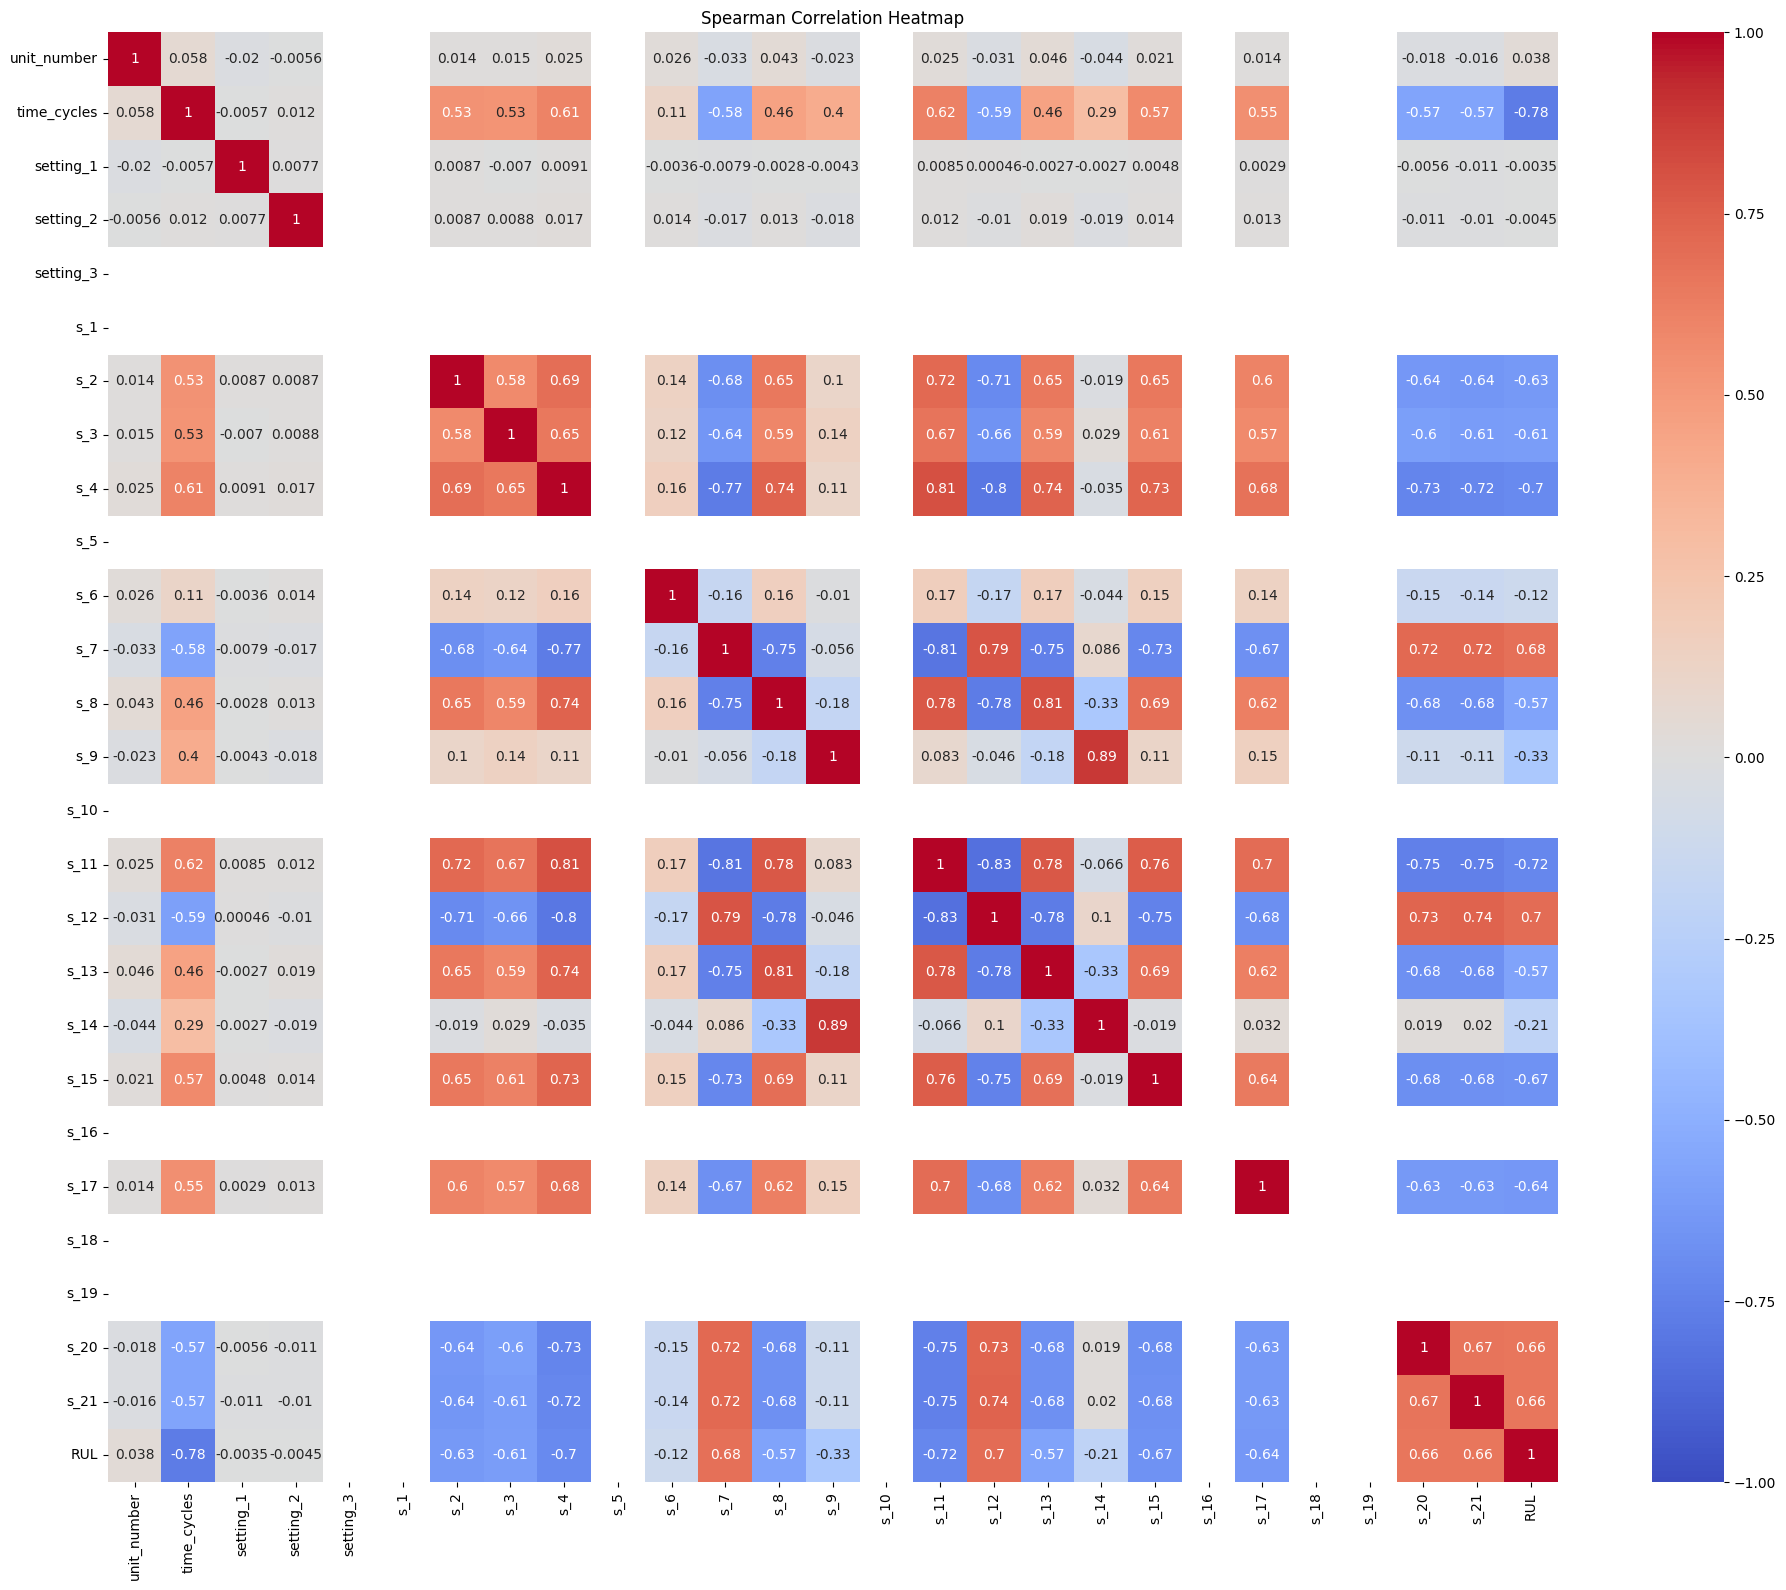

In [9]:
corr = df.corr(method='spearman')
plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()

Drop the Bloat Sensors Identified Namely:

s1 s5 s6 s10 s16 s18 s19

In [10]:
df = df.drop(['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19'], axis=1)

Applying Feature Scaling by standard scaler


In [11]:
from sklearn.preprocessing import StandardScaler

# Identify the columns that are not features (identifiers or target)
non_feature_cols = ['unit_number', 'time_cycles', 'RUL']

# The actual feature columns remaining in df after dropping bloat sensors
current_feature_cols = df.columns.drop(non_feature_cols).tolist()

# Separate df into non-feature parts and feature parts
df_non_features = df[non_feature_cols]
df_features = df[current_feature_cols]

scaler = StandardScaler()

# Fit and transform only the feature columns
scaled_features_array = scaler.fit_transform(df_features)

# Create a DataFrame from the scaled features
scaled_df_features = pd.DataFrame(scaled_features_array, columns=current_feature_cols, index=df.index)

# Recombine the non-feature columns with the scaled feature columns
df = pd.concat([df_non_features, scaled_df_features], axis=1)

Sliding Window Generation

To create : windows of size 30 time steps
with target -> RUL at the end of their cycle



In [12]:
import numpy as np

def sliding_window(df, sequence_length=30):
    X = [] # List to store sequences of features
    y = [] # List to store RUL targets


    for unit_number in df['unit_number'].unique():
        unit_df = df[df['unit_number'] == unit_number].copy()


        features = unit_df.drop(columns=['unit_number', 'time_cycles', 'RUL'])


        for i in range(len(unit_df) - sequence_length + 1):

            X.append(features.iloc[i : i + sequence_length].values)


            y.append(unit_df['RUL'].iloc[i + sequence_length - 1])

    return np.array(X), np.array(y)

Now, let's use the `sliding_window` function to create the feature sequences (`X`) and the corresponding Remaining Useful Life (`y`) targets with a sequence length of 30.

In [73]:
sequence_length = 60
X, y = sliding_window(df, sequence_length=sequence_length)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of targets (y): {y.shape}")

Shape of features (X): (14731, 60, 17)
Shape of targets (y): (14731,)


Make Dataloader for our training dataset

In [74]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Add a dimension for RUL target

# Create a TensorDataset
dataset = TensorDataset(X_tensor, y_tensor)

# Define batch size
batch_size = 32

# Create a DataLoader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Shape of X_tensor: {X_tensor.shape}")
print(f"Shape of y_tensor: {y_tensor.shape}")
print(f"Number of batches in DataLoader: {len(dataloader)}")

# Optionally, inspect one batch
for features, targets in dataloader:
    print(f"Batch features shape: {features.shape}")
    print(f"Batch targets shape: {targets.shape}")
    break

Shape of X_tensor: torch.Size([14731, 60, 17])
Shape of y_tensor: torch.Size([14731, 1])
Number of batches in DataLoader: 461
Batch features shape: torch.Size([32, 60, 17])
Batch targets shape: torch.Size([32, 1])


Defining our LSTM Model

In [75]:
import torch.nn as nn

class TurbofanLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout_prob=0.3):
        super(TurbofanLSTM, self).__init__()
        # LSTM layer to process sequential data
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True,
                            dropout=dropout_prob if num_layers > 1 else 0)
        # Regularization layer to prevent overfitting
        self.dropout = nn.Dropout(dropout_prob)
        # Fully connected layer to output RUL prediction
        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.out = nn.Linear(16, 1)

    def forward(self, x):
        # x shape: (Batch Size, Sequence Length, Features)
        # For this dataset, x shape: (Batch Size, 30, 17) based on previous steps
        # LSTM output returns: (output, (hn, cn))
        # output: (Batch Size, Sequence Length, hidden_size)
        # hn: (num_layers, Batch Size, hidden_size) - final hidden state for each layer
        # cn: (num_layers, Batch Size, hidden_size) - final cell state for each layer
        lstm_out, (hn, cn) = self.lstm(x)

        # We are interested in the output of the last time step for RUL prediction
        last_time_step = lstm_out[:, -1, :]

        # Pass through dropout, FC layers, and ReLU activation
        x = self.dropout(last_time_step)
        x = self.fc1(x)
        x = self.relu(x)
        rul_prediction = self.out(x)

        # Squeeze to remove the extra dimension (e.g., (batch_size, 1) -> (batch_size))
        return rul_prediction.squeeze()

Instantiate The Model

In [76]:
# Define model parameters
input_size = X.shape[2] # Number of features
hidden_size = 64 # Number of features in the hidden state of the LSTM
num_layers = 2 # Number of recurrent layers
dropout_prob = 0.2 # Dropout rate for regularization

# Instantiate the model
model = TurbofanLSTM(input_size, hidden_size, num_layers, dropout_prob)

# Print the model architecture
print(model)

TurbofanLSTM(
  (lstm): LSTM(17, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=16, bias=True)
  (relu): ReLU()
  (out): Linear(in_features=16, out_features=1, bias=True)
)


Training Loop for our lstm

In [77]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

In [78]:
import torch
import torch.nn as nn  # Needed for TurbofanLSTM and nn.MSELoss
import torch.optim as optim  # Needed for optim.Adam
import torch.optim.lr_scheduler # Import for learning rate scheduler

# Re-define model instantiation parameters (from cell tJ_Vg9E6DCjC)
# Assuming input_size was 17 from X.shape[2] after cell 92b71a75
input_size = 17
hidden_size = 64
num_layers = 2
dropout_prob = 0.2

# Re-instantiate the model (TurbofanLSTM class defined in JxiqKKMdCZQK)
# This assumes the TurbofanLSTM class definition is available in the global scope.
model = TurbofanLSTM(input_size, hidden_size, num_layers, dropout_prob)

# Re-define loss function and optimizer (from cell xjxCJ1-MD7RL)
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define a learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs):
    model.to(device) # Move model to the selected device
    model.train() # Set the model to training mode
    epoch_losses = [] # List to store loss for each epoch

    for epoch in range(num_epochs):
        total_loss = 0
        for batch_idx, (features, targets) in enumerate(dataloader):
            # Move data to the selected device
            features = features.to(device)
            targets = targets.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(features)

            # Calculate loss
            loss = criterion(outputs, targets.squeeze(1)) # .squeeze(1) to match output shape

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        epoch_losses.append(avg_loss)
        current_lr = optimizer.param_groups[0]['lr'] # Get current LR from optimizer
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Learning Rate: {current_lr:.6f}")

        # Step the scheduler at the end of each epoch, passing the monitored metric
        scheduler.step(avg_loss)

    print("Training finished.")
    return epoch_losses

# Example usage:
num_epochs = 80 # You can adjust this number
print("Starting training...")
losses = train_model(model, dataloader, criterion, optimizer, scheduler, num_epochs)

Using device: cuda
Starting training...
Epoch [1/80], Loss: 40.8631, Learning Rate: 0.001000
Epoch [2/80], Loss: 11.4026, Learning Rate: 0.001000
Epoch [3/80], Loss: 8.7487, Learning Rate: 0.001000
Epoch [4/80], Loss: 8.0204, Learning Rate: 0.001000
Epoch [5/80], Loss: 7.6123, Learning Rate: 0.001000
Epoch [6/80], Loss: 7.0445, Learning Rate: 0.001000
Epoch [7/80], Loss: 7.0288, Learning Rate: 0.001000
Epoch [8/80], Loss: 6.5809, Learning Rate: 0.001000
Epoch [9/80], Loss: 6.4168, Learning Rate: 0.001000
Epoch [10/80], Loss: 6.0865, Learning Rate: 0.001000
Epoch [11/80], Loss: 5.9305, Learning Rate: 0.001000
Epoch [12/80], Loss: 5.7551, Learning Rate: 0.001000
Epoch [13/80], Loss: 5.6211, Learning Rate: 0.001000
Epoch [14/80], Loss: 5.4141, Learning Rate: 0.001000
Epoch [15/80], Loss: 5.2497, Learning Rate: 0.001000
Epoch [16/80], Loss: 5.0027, Learning Rate: 0.001000
Epoch [17/80], Loss: 4.8390, Learning Rate: 0.001000
Epoch [18/80], Loss: 4.8243, Learning Rate: 0.001000
Epoch [19/80]

Now that the model is trained, let's save its weights so we can reuse it later without retraining.

In [79]:
model_save_path = 'model_weights.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

Model weights saved to model_weights.pth


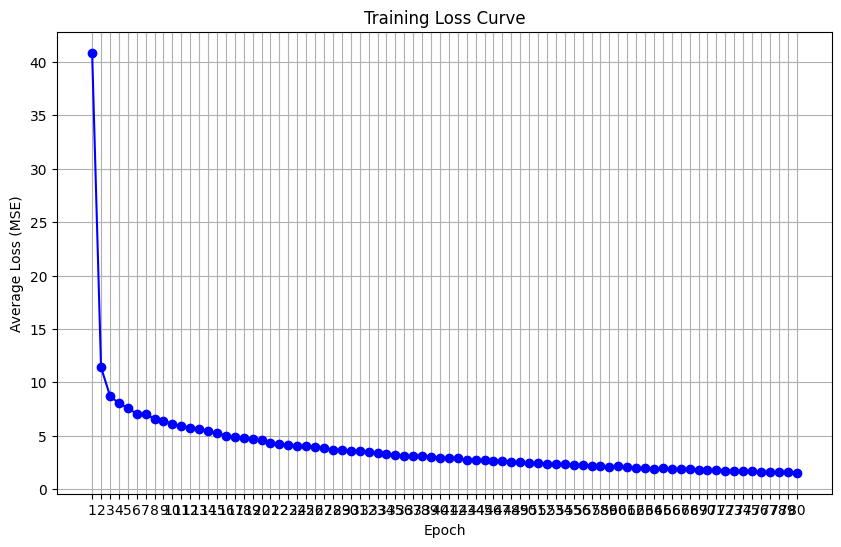

In [80]:
import matplotlib.pyplot as plt

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-', color='blue')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Average Loss (MSE)')
plt.grid(True)
plt.xticks(range(1, len(losses) + 1)) # Ensure all epochs are shown on x-axis
plt.show()

## Evaluate Model Performance

To evaluate the model, we need to load the test data and apply the same preprocessing steps as we did for the training data.

In [81]:
import pandas as pd
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1,22)]
col_names = index_names + setting_names + sensor_names

# Load test data
df_test = pd.read_csv('/content/sample_data/test_FD001.txt', sep=r'\s+', header=None, names=col_names)

# Load true RUL values for the test set
rul_test = pd.read_csv('/content/sample_data/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL_actual'])
# Add unit_number to rul_test as it's implicitly ordered from 1 to 100
rul_test['unit_number'] = rul_test.index + 1

# Calculate max_cycle for the test data, similar to training data
max_cycle_test = df_test.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycle_test.columns = ['unit_number', 'max_cycle']
df_test = pd.merge(df_test, max_cycle_test, on='unit_number', how='left')

# Merge rul_test with df_test to get the actual RUL values at the end of life
df_test = pd.merge(df_test, rul_test, on='unit_number', how='left')

# Calculate RUL for all cycles in the test set
df_test['RUL'] = df_test['max_cycle'] - df_test['time_cycles'] + df_test['RUL_actual']

# Apply RUL clipping to test data (using the same clip value as training)
rul_clip = 125
df_test['RUL'] = df_test['RUL'].clip(upper=rul_clip)

# Drop the temporary 'max_cycle' and 'RUL_actual' columns
df_test.drop(columns=['max_cycle', 'RUL_actual'], inplace=True)

print(f"Shape of df_test after RUL calculation: {df_test.shape}")
display(df_test.head())

Shape of df_test after RUL calculation: (13096, 27)


,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,125
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,125
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,125
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,125
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,125


Now, apply the same feature dropping and scaling as done for the training set. It's crucial to use the *same* `StandardScaler` that was `fit` on the training data to ensure consistency.

In [82]:
# Drop the same bloat sensors as in the training data
df_test_processed = df_test.drop(['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19'], axis=1)

# Identify the columns that are not features (identifiers or target) - same as training
non_feature_cols = ['unit_number', 'time_cycles', 'RUL']

# The actual feature columns remaining in df_test_processed after dropping bloat sensors
current_test_feature_cols = df_test_processed.columns.drop(non_feature_cols).tolist()

# Separate df_test_processed into non-feature parts and feature parts
df_test_non_features = df_test_processed[non_feature_cols]
df_test_features = df_test_processed[current_test_feature_cols]

# Apply the *already fitted* scaler (from cell 8iIMBsAkQ3cp) to the test features ONLY
# The 'scaler' object from cell 8iIMBsAkQ3cp should be fitted on the training features only.
scaled_test_features_array = scaler.transform(df_test_features)

# Create a DataFrame from the scaled test features
scaled_df_test_features = pd.DataFrame(scaled_test_features_array, columns=current_test_feature_cols, index=df_test_processed.index)

# Recombine the non-feature columns with the scaled feature columns
df_test_processed = pd.concat([df_test_non_features, scaled_df_test_features], axis=1)

print(f"Shape of df_test_processed after scaling: {df_test_processed.shape}")
display(df_test_processed.head())

Shape of df_test_processed after scaling: (13096, 20)


,unit_number,time_cycles,RUL,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,1,125,1.055599,1.015677,0.0,0.678077,-0.853550,-1.191480,0.601408,-0.798093,-0.682579,-1.277396,0.415614,-0.919841,-0.954235,-0.985107,-0.781710,0.241943,0.774097
1,1,2,125,-1.230366,-1.031720,0.0,-1.941707,-0.338137,-1.501467,1.674769,-1.220725,-0.490117,-0.154141,1.012195,-0.502695,-0.216648,-1.649034,-0.136018,1.127183,0.941305
2,1,3,125,0.141213,0.333211,0.0,-0.441831,-0.584426,-0.843717,0.838677,-0.657216,-0.375093,-0.154141,0.754581,-0.919841,-0.715712,0.052112,-0.136018,1.459148,1.172256
3,1,4,125,1.924266,-0.008022,0.0,-0.481827,-1.044384,-0.279297,0.793483,-0.938970,-0.903570,-0.977861,-0.045381,-0.641744,-0.568929,-1.345067,-1.427402,1.016528,0.775945
4,1,5,125,0.644125,-0.008022,0.0,-0.341839,-0.543650,-0.779276,0.895170,-1.220725,-0.937081,-0.865536,0.998637,-0.919841,-0.745069,-1.041101,-2.073094,0.961200,1.138999


Now, generate the sliding windows for the preprocessed test data using the `sliding_window` function and create a DataLoader.

In [83]:
# Generate sliding windows for the test data
X_test, y_test = sliding_window(df_test_processed, sequence_length=sequence_length)

# Convert to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create TensorDataset and DataLoader for the test set
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # No shuffling for evaluation

print(f"Shape of X_test_tensor: {X_test_tensor.shape}")
print(f"Shape of y_test_tensor: {y_test_tensor.shape}")
print(f"Number of batches in test DataLoader: {len(test_dataloader)}")

Shape of X_test_tensor: torch.Size([7351, 60, 17])
Shape of y_test_tensor: torch.Size([7351, 1])
Number of batches in test DataLoader: 230


### Model Evaluation

Now, let's evaluate the trained model on the test dataset. We will calculate Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2) score.

In [84]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np # Import numpy for array conversion
import torch # Ensure torch is imported for device operations

def evaluate_model(model, dataloader, criterion):
    model.eval() # Set the model to evaluation mode
    total_loss = 0
    all_predictions = []
    all_targets = []

    # Get the device from the model
    device = next(model.parameters()).device

    with torch.no_grad(): # Disable gradient calculation during evaluation
        for features, targets in dataloader:
            # Move data to the selected device (CPU or CUDA)
            features = features.to(device)
            targets = targets.to(device)

            outputs = model(features)
            loss = criterion(outputs, targets.squeeze(1))
            total_loss += loss.item()

            all_predictions.extend(outputs.cpu().numpy().tolist())
            all_targets.extend(targets.squeeze(1).cpu().numpy().tolist())

    # Convert lists to numpy arrays for metric calculation
    all_predictions_np = np.array(all_predictions)
    all_targets_np = np.array(all_targets)

    return all_predictions_np, all_targets_np

print("Starting evaluation...")
predictions, actuals = evaluate_model(model, test_dataloader, criterion)
print("Evaluation finished.")

# Calculate metrics using the returned predictions and actuals
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

Starting evaluation...
Evaluation finished.
MSE : 295.1581
RMSE: 17.1802
MAE : 12.1262
R²  : 0.7140


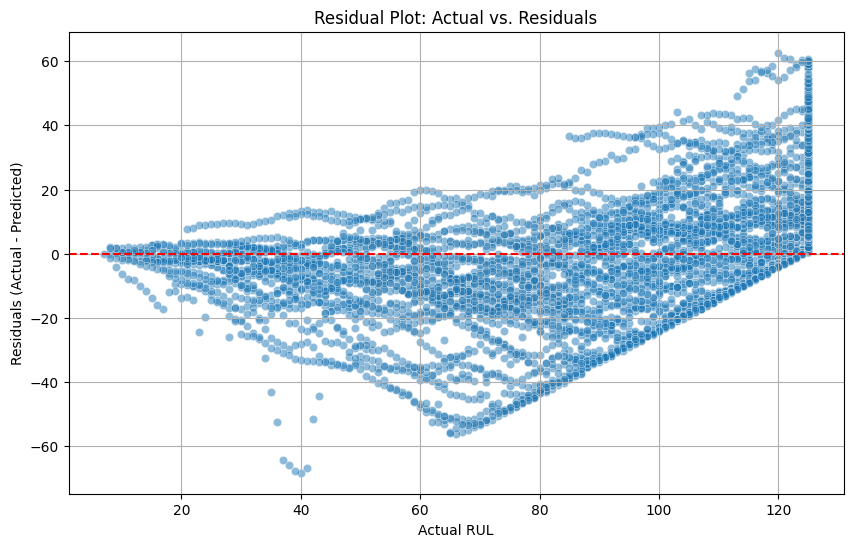

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = actuals - predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=actuals, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual RUL')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Actual vs. Residuals')
plt.grid(True)
plt.show()


This residual plot shows the difference between the actual RUL values and the predicted RUL values. Ideally, the residuals should be randomly scattered around zero, indicating that the model's predictions are unbiased. Any discernible patterns in this plot could suggest areas where the model might be systematically over or under-predicting.

In [26]:
print(df["RUL"].min())
print(feature_cols)

0
Index(['setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4',
       's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13',
       's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21'],
      dtype='object')
